# Video Inpainting with Local Anime Clips

This notebook demonstrates anime-style video inpainting using a local video clip and a pretrained Stable Diffusion inpainting model. We progressively move from single-frame inpainting to short video inpainting and then analyze how guidance strength affects reconstruction quality, perceptual realism, and consistency.

## 1) Setup local paths and device


In [3]:
from pathlib import Path
import os
import gc
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

# Project paths
PROJECT_ROOT = Path("/Users/arushisingh/deep-learning-video-inpainting-project")
DATA_ROOT = Path("/Users/arushisingh/Desktop/jacoblin_50clips")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "clean_inpainting"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
elif torch.backends.mps.is_available():
    device = "mps"
    dtype = torch.float32  # safest on Mac/MPS
else:
    device = "cpu"
    dtype = torch.float32

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("device:", device)
print("dtype:", dtype)

assert PROJECT_ROOT.exists(), f"Project root not found: {PROJECT_ROOT}"
assert DATA_ROOT.exists(), f"Clip folder not found: {DATA_ROOT}"

PROJECT_ROOT: /Users/arushisingh/deep-learning-video-inpainting-project
DATA_ROOT: /Users/arushisingh/Desktop/jacoblin_50clips
OUTPUT_DIR: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting
device: mps
dtype: torch.float32


## 2) Find clips and lock the selected video/frame


In [4]:
# Remove hidden Mac metadata files like ._36837.mp4
video_paths = sorted(
    [p for p in DATA_ROOT.glob("*.mp4") if p.is_file() and not p.name.startswith("._")]
)

print("Num real clips:", len(video_paths))
print([p.name for p in video_paths[:10]])

# Final selected clip/frame from our screening
SELECTED_CLIP_NAME = "36877.mp4"
FRAME_ID = 25535

video_path = next(p for p in video_paths if p.name == SELECTED_CLIP_NAME)
print("Using video:", video_path)
print("Using frame:", FRAME_ID)

Num real clips: 25
['36837.mp4', '36838.mp4', '36839.mp4', '36840.mp4', '36841.mp4', '36842.mp4', '36846.mp4', '36849.mp4', '36850.mp4', '36851.mp4']
Using video: /Users/arushisingh/Desktop/jacoblin_50clips/36877.mp4
Using frame: 25535


## 3) Load the exact frame we want to inpaint


Frame shape: (360, 640, 3)
Min/Max: 0 255


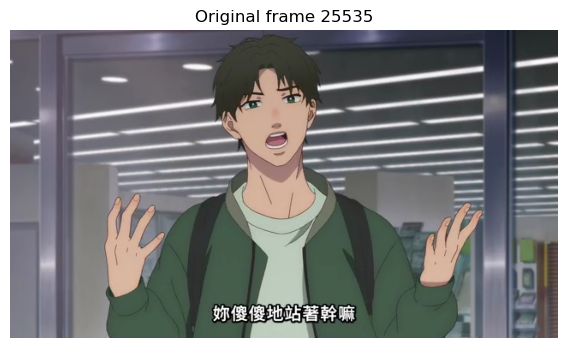

In [5]:
def read_frame_at(video_path, frame_id):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()
    cap.release()
    if not ret or frame is None:
        raise RuntimeError(f"Could not read frame {frame_id} from {video_path}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


frame = read_frame_at(video_path, FRAME_ID)
H, W, _ = frame.shape

print("Frame shape:", frame.shape)
print("Min/Max:", frame.min(), frame.max())

plt.figure(figsize=(8, 4))
plt.imshow(frame)
plt.title(f"Original frame {FRAME_ID}")
plt.axis("off")
plt.show()

## 4) Build a tighter mask for the right hand / moving region

This mask is intentionally more accurate than the old centered black square. Adjust the coordinates if you want to cover a slightly different area. White = region to inpaint.


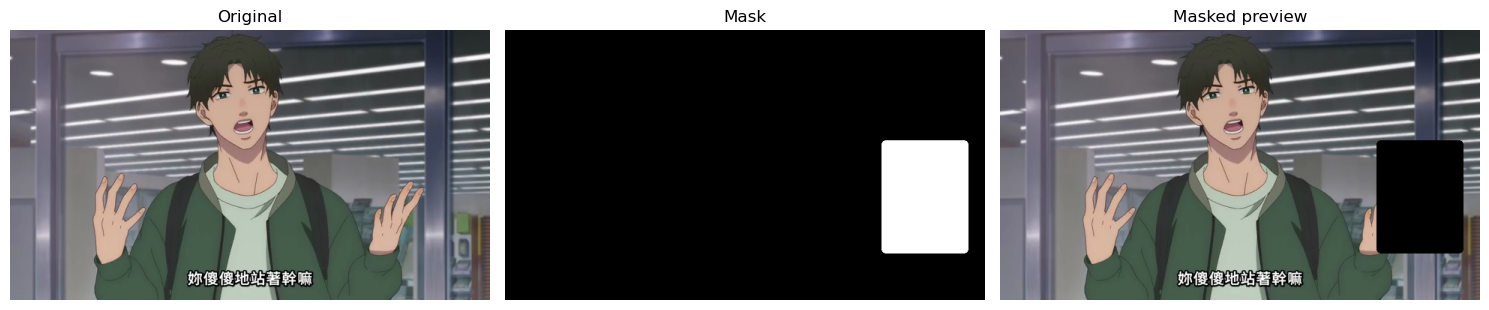

Frame size (W,H): 640 360
Mask unique values: [  0 255] ... [  0 255]


In [6]:
# Create a tighter, hand-focused mask.
# Coordinates are tuned for frame 25535 of 36877.mp4.
mask = np.zeros((H, W), dtype=np.uint8)

# Right hand region. Tweak these numbers if needed.
x1, x2 = 505, 615
y1, y2 = 150, 295

# Use a rounded/elliptical-ish mask instead of a harsh giant square.
# Start with a rectangle and soften the edges slightly.
mask[y1:y2, x1:x2] = 255

# Optional: make the mask less blocky by adding a slight blur.
# Keep this small so the mask still stays accurate.
mask_image_preview = Image.fromarray(mask).filter(ImageFilter.GaussianBlur(radius=2))
mask = np.array(mask_image_preview)
mask = (mask > 20).astype(np.uint8) * 255

masked_preview = frame.copy()
masked_preview[mask > 0] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(frame)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(masked_preview)
axes[2].set_title("Masked preview")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Frame size (W,H):", W, H)
print("Mask unique values:", np.unique(mask)[:10], "...", np.unique(mask)[-10:])

## 5) Convert frame and mask to PIL images


init_image size: (640, 360)
mask_image size: (640, 360)


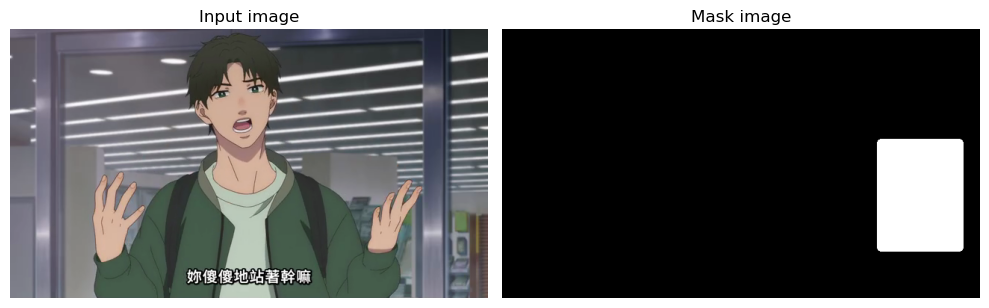

In [7]:
init_image = Image.fromarray(frame.astype(np.uint8)).convert("RGB")
mask_image = Image.fromarray(mask.astype(np.uint8)).convert("L")

print("init_image size:", init_image.size)
print("mask_image size:", mask_image.size)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Mask image")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 1: Single-Frame Conditional Inpainting Baseline

For Task 1, we use a pretrained Stable Diffusion Inpainting pipeline as the conditional inpainting baseline. The model receives three inputs:

1. the original anime frame,
2. a binary mask showing the missing region,
3. a text prompt describing the desired anime-style reconstruction.

The goal is to reconstruct the masked hand region while preserving the surrounding context.

Given an input image \(x\), mask \(m\), and prompt condition \(c\), the model generates an inpainted image:

$$
\hat{x} = f_{\theta}(x, m, c)
$$

where $f_{\theta}$ is the pretrained Stable Diffusion inpainting model.

## 6) Load Stable Diffusion inpainting pipeline

This uses the same route as the original Nintendo notebook. It will reuse your local Hugging Face cache if already available. It does **not** download base SD or AnimateDiff.


In [8]:
from diffusers import StableDiffusionInpaintPipeline

# Clear a little memory before loading.
gc.collect()
if device == "mps":
    torch.mps.empty_cache()

if "inpaint_pipe" in globals():
    print("Reusing already-loaded inpaint_pipe")
else:
    inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
        "stable-diffusion-v1-5/stable-diffusion-inpainting",
        torch_dtype=dtype,
        safety_checker=None,
        requires_safety_checker=False,
    )
    inpaint_pipe = inpaint_pipe.to(device)
    if device != "cpu":
        inpaint_pipe.enable_attention_slicing()
    print("Loaded inpaint_pipe")

print(type(inpaint_pipe))

W0424 15:06:47.715000 73887 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
unet/diffusion_pytorch_model.safetensors not found


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Loaded inpaint_pipe
<class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'>


# Task 2A: Extending Inpainting to Nearby Video Frames

For Task 2, we apply the same inpainting pipeline to a short window of nearby frames. This allows us to evaluate whether the model produces visually coherent results when used frame-by-frame on video data.

The same mask is reused across the sampled frames to keep the experiment controlled and focused on the moving hand region.

## 7) Single-frame inpainting test

This should preserve the rectangular frame shape. If your installed Diffusers version still returns a square image, the code resizes the output back for display/save.


  0%|          | 0/18 [00:00<?, ?it/s]

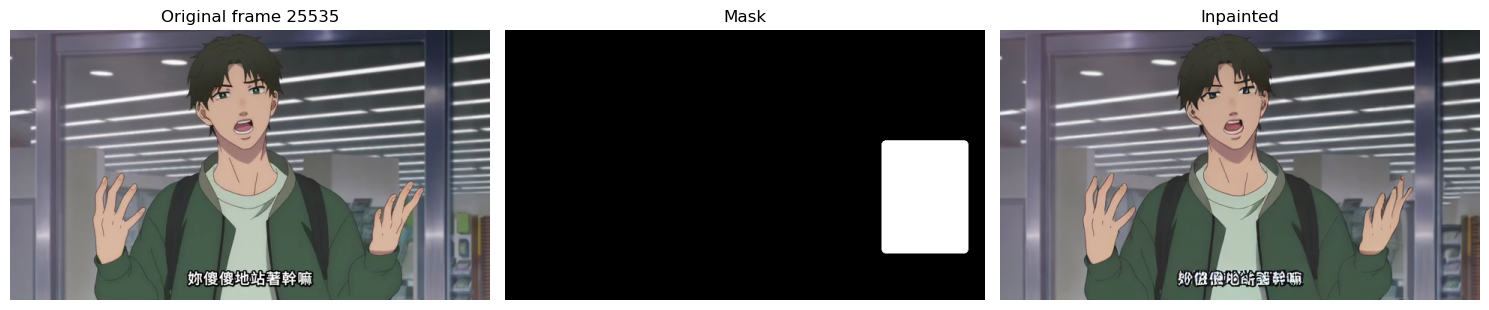

In [9]:
prompt = (
    "anime young man speaking indoors, expressive hands, clean anime linework, "
    "consistent character design, smooth shading, high quality"
)
negative_prompt = (
    "blurry, noisy, distorted, warped face, bad anatomy, extra fingers, extra hands, "
    "deformed hands, duplicate limbs, artifacts, text, watermark, worst quality"
)

# Important: pass height and width to avoid square output.
result = inpaint_pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    height=H,
    width=W,
    num_inference_steps=25,
    guidance_scale=7.5,
    strength=0.75,
).images[0]

# Safety: if the pipeline returns a square anyway, resize back to original aspect for consistency.
if result.size != init_image.size:
    print("Resizing result from", result.size, "to", init_image.size)
    result = result.resize(init_image.size, Image.Resampling.BICUBIC)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(init_image)
axes[0].set_title(f"Original frame {FRAME_ID}")
axes[0].axis("off")

axes[1].imshow(mask_image, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(result)
axes[2].set_title("Inpainted")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 8) Save single-frame result


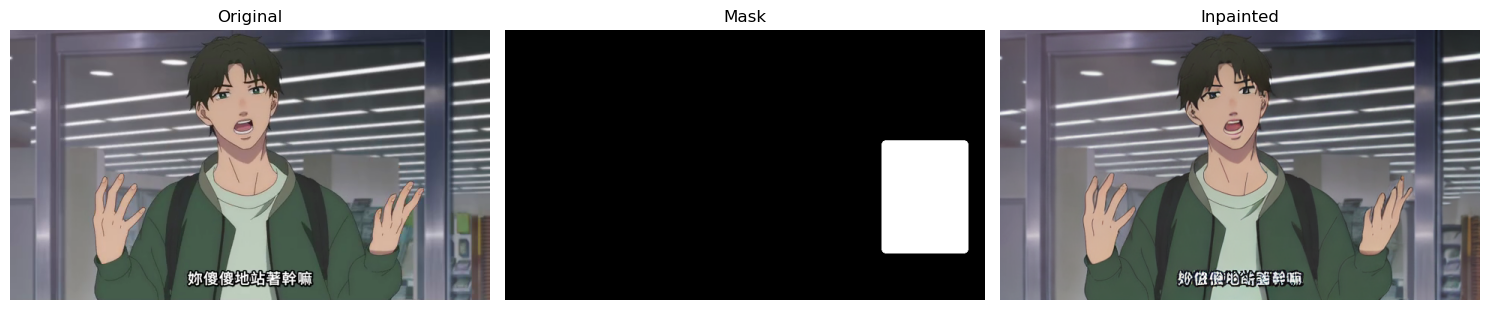

Saved result: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_frame_25535_inpaint.png
Saved comparison: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_frame_25535_comparison.png


In [10]:
single_path = OUTPUT_DIR / f"{video_path.stem}_frame_{FRAME_ID}_inpaint.png"
comparison_path = OUTPUT_DIR / f"{video_path.stem}_frame_{FRAME_ID}_comparison.png"

result.save(single_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(init_image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(mask_image, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")
axes[2].imshow(result)
axes[2].set_title("Inpainted")
axes[2].axis("off")
plt.tight_layout()
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved result:", single_path)
print("Saved comparison:", comparison_path)

## 9) Optional: nearby-frame GIF using the same mask

This follows the original notebook’s simple frame-by-frame method. It is optional, but useful for the report because it creates an actual GIF.


Loaded frames: [25527, 25529, 25531, 25533, 25535, 25537, 25539, 25541]


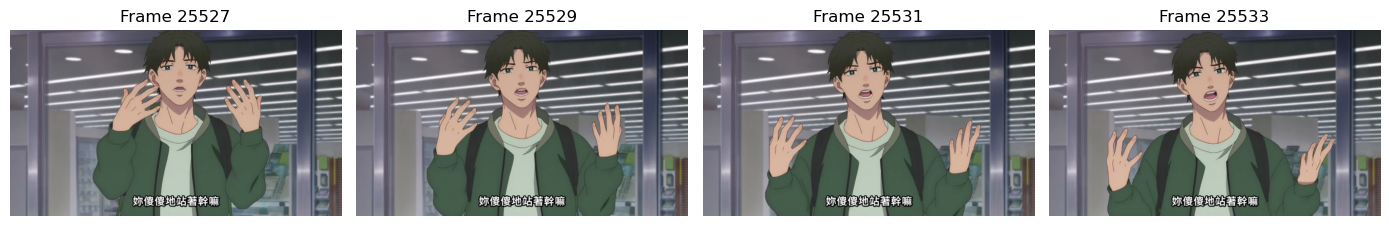

In [11]:
# Load a short window around the selected frame.
# Keep this small for speed.
NUM_FRAMES = 8
STRIDE = 2
START_FRAME = FRAME_ID - (NUM_FRAMES // 2) * STRIDE

segment_frames = []
segment_frame_ids = []
for k in range(NUM_FRAMES):
    fid = START_FRAME + k * STRIDE
    segment_frames.append(read_frame_at(video_path, fid))
    segment_frame_ids.append(fid)

print("Loaded frames:", segment_frame_ids)

sample_ids = list(range(min(4, len(segment_frames))))
fig, axes = plt.subplots(1, len(sample_ids), figsize=(14, 4))
if len(sample_ids) == 1:
    axes = [axes]
for ax, idx in zip(axes, sample_ids):
    ax.imshow(segment_frames[idx])
    ax.set_title(f"Frame {segment_frame_ids[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
from tqdm import tqdm
import imageio.v2 as imageio

# Reuse the exact same mask for the short GIF.
# This is the simple baseline method from the Nintendo notebook.
gif_results = []

for frame_np in tqdm(segment_frames):
    frame_pil = Image.fromarray(frame_np.astype(np.uint8)).convert("RGB")
    mask_pil = mask_image

    out = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=frame_pil,
        mask_image=mask_pil,
        height=H,
        width=W,
        num_inference_steps=20,
        guidance_scale=7.5,
        strength=0.75,
    ).images[0]

    if out.size != frame_pil.size:
        out = out.resize(frame_pil.size, Image.Resampling.BICUBIC)

    gif_results.append(out)

print("Finished GIF frames:", len(gif_results))

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:15<01:45, 15.10s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

 25%|██▌       | 2/8 [00:30<01:30, 15.05s/it]

...

  0%|          | 0/15 [00:00<?, ?it/s]

 88%|████████▊ | 7/8 [01:47<00:15, 15.44s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 8/8 [02:03<00:00, 15.39s/it]

Finished GIF frames: 8


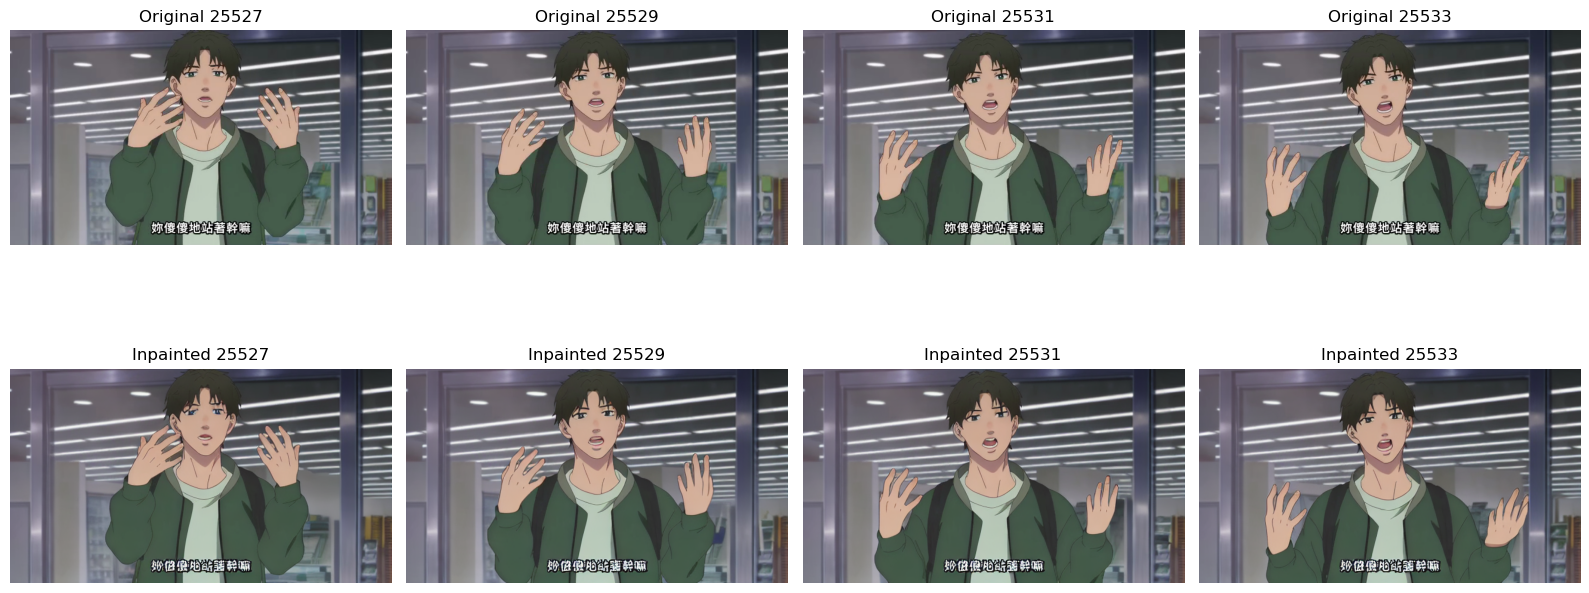

In [13]:
# Preview first few original vs inpainted frames
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0, i].imshow(segment_frames[i])
    axes[0, i].set_title(f"Original {segment_frame_ids[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(gif_results[i])
    axes[1, i].set_title(f"Inpainted {segment_frame_ids[i]}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [14]:
# Save GIF + MP4
from diffusers.utils import export_to_gif

baseline_gif = OUTPUT_DIR / f"{video_path.stem}_inpainting_baseline.gif"
baseline_mp4 = OUTPUT_DIR / f"{video_path.stem}_inpainting_baseline.mp4"

export_to_gif(gif_results, str(baseline_gif))

# MP4 export via imageio
imageio.mimsave(
    baseline_mp4,
    [np.array(img) for img in gif_results],
    fps=5,
    codec="libx264",
)

print("Saved GIF:", baseline_gif)
print("Saved MP4:", baseline_mp4)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 360) to (640, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved GIF: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_inpainting_baseline.gif
Saved MP4: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_inpainting_baseline.mp4


## 10) Optional: simple temporal guidance comparison

This keeps the same idea from the original notebook: blend the previous output into the next input inside the masked region. It is not true AnimateDiff, but it is a simple guidance mechanism you can explain for Task III.


In [15]:
def blend_with_previous(current_frame_pil, prev_result_pil, mask_pil, alpha=0.7):
    prev_result_pil = prev_result_pil.resize(
        current_frame_pil.size, Image.Resampling.BILINEAR
    )

    current = np.array(current_frame_pil).astype(np.float32)
    prev = np.array(prev_result_pil).astype(np.float32)
    m = np.array(mask_pil).astype(np.float32) / 255.0
    m3 = np.repeat(m[:, :, None], 3, axis=2)

    guided = current * (1 - m3) + (alpha * prev + (1 - alpha) * current) * m3
    return Image.fromarray(np.clip(guided, 0, 255).astype(np.uint8))


def run_guided_inpainting(frames_list, alpha=0.7):
    guided_results = []

    for i, frame_np in enumerate(tqdm(frames_list)):
        frame_pil = Image.fromarray(frame_np.astype(np.uint8)).convert("RGB")

        if i == 0:
            guided_input = frame_pil
        else:
            guided_input = blend_with_previous(
                frame_pil, guided_results[-1], mask_image, alpha=alpha
            )

        out = inpaint_pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=guided_input,
            mask_image=mask_image,
            height=H,
            width=W,
            num_inference_steps=20,
            guidance_scale=7.5,
            strength=0.75,
        ).images[0]

        if out.size != frame_pil.size:
            out = out.resize(frame_pil.size, Image.Resampling.BICUBIC)

        guided_results.append(out)

    return guided_results

In [16]:
alpha_values = [0.3, 0.7]
guided_experiments = {}

for alpha in alpha_values:
    print("Running alpha =", alpha)
    guided_experiments[alpha] = run_guided_inpainting(segment_frames, alpha=alpha)

print("Finished guided experiments")

Running alpha = 0.3


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:15<01:51, 15.88s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

 88%|████████▊ | 7/8 [02:10<00:18, 18.95s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 8/8 [02:29<00:00, 18.71s/it]

Finished guided experiments


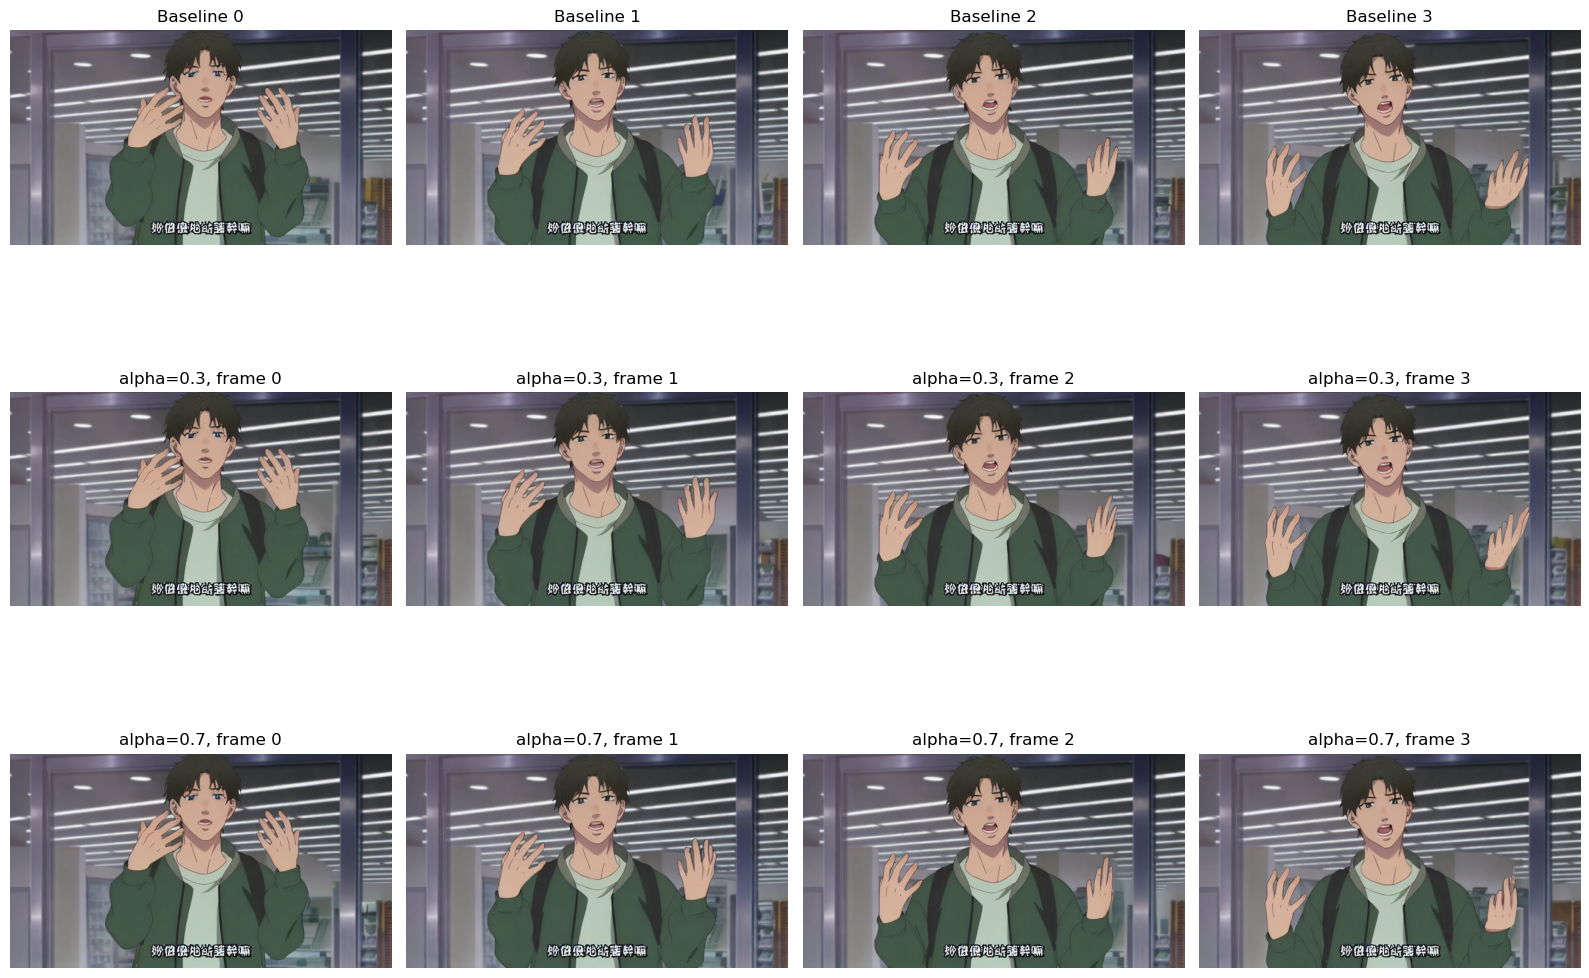

In [17]:
# Compare baseline and guided results
fig, axes = plt.subplots(
    1 + len(alpha_values), 4, figsize=(16, 4 * (1 + len(alpha_values)))
)

for i in range(4):
    axes[0, i].imshow(gif_results[i])
    axes[0, i].set_title(f"Baseline {i}")
    axes[0, i].axis("off")

for r, alpha in enumerate(alpha_values, start=1):
    for i in range(4):
        axes[r, i].imshow(guided_experiments[alpha][i])
        axes[r, i].set_title(f"alpha={alpha}, frame {i}")
        axes[r, i].axis("off")

plt.tight_layout()
plt.show()

In [18]:
for alpha, imgs in guided_experiments.items():
    tag = str(alpha).replace(".", "_")
    gif_path = OUTPUT_DIR / f"{video_path.stem}_guided_alpha_{tag}.gif"
    export_to_gif(imgs, str(gif_path))
    print("Saved:", gif_path)

# Save these to mp4 as well
for alpha, imgs in guided_experiments.items():
    tag = str(alpha).replace(".", "_")
    mp4_path = OUTPUT_DIR / f"{video_path.stem}_guided_alpha_{tag}.mp4"
    imageio.mimsave(
        mp4_path,
        [np.array(img) for img in imgs],
        fps=5,
        codec="libx264",
    )
    print("Saved:", mp4_path)

Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_3.gif


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 360) to (640, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 360) to (640, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_7.gif
Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_3.mp4
Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_7.mp4


# Task 2B: Conditional VAE Baseline Trained from Scratch

The previous Task 2 section applies a pretrained Stable Diffusion inpainting model frame-by-frame. However, the assignment also asks for a conditional inpainting baseline that does not rely on an unconditional generative prior.

To satisfy this requirement, we train a lightweight conditional Variational Autoencoder (VAE) from scratch. The model receives a masked frame and its binary mask as input, then predicts the reconstructed frame. Unlike Stable Diffusion, this baseline does not use a pretrained image prior or text prompt.

The model input is:

$$
[x_t \odot (1 - m_t),\; m_t]
$$

where $x_t$ is the original frame and $m_t$ is the binary mask.

The conditional VAE learns a latent representation $z$ of the masked input and reconstructs the missing region:

$$
z \sim q_{\phi}(z \mid x_t \odot (1 - m_t), m_t)
$$

$$
\hat{x}_t = p_{\theta}(x_t \mid z, x_t \odot (1 - m_t), m_t)
$$

The training objective combines masked reconstruction loss with KL divergence:

$$
\mathcal{L}
=
\left\|
m_t \odot (\hat{x}_t - x_t)
\right\|_1
+
\beta D_{KL}
\left(
q_{\phi}(z \mid x_t \odot (1 - m_t), m_t)
\;\|\;
\mathcal{N}(0, I)
\right)
$$

This conditional VAE serves as the no-prior baseline. We expect it to capture coarse structure and color, but it may produce blurrier outputs than the pretrained diffusion model because it is trained only on our local anime clips.

In [26]:
# Task 2B - Step 1: Imports and setup for conditional U-Net baseline

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

Using device: cpu


In [ ]:
# Task 2B - Step 7: Easier dataset with smaller random masks


class AnimeInpaintingDatasetSmallMask(Dataset):
    def __init__(self, frames, image_size=128, num_augments_per_frame=60):
        self.frames = frames
        self.image_size = image_size
        self.num_augments_per_frame = num_augments_per_frame

    def __len__(self):
        return len(self.frames) * self.num_augments_per_frame

    def random_rectangle_mask(self, h, w):
        mask = np.zeros((h, w), dtype=np.float32)

        mask_h = random.randint(h // 8, h // 4)
        mask_w = random.randint(w // 8, w // 4)

        y1 = random.randint(0, h - mask_h)
        x1 = random.randint(0, w - mask_w)

        mask[y1 : y1 + mask_h, x1 : x1 + mask_w] = 1.0
        return mask

    def __getitem__(self, idx):
        frame_idx = idx % len(self.frames)
        img = Image.fromarray(self.frames[frame_idx].astype(np.uint8)).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.Resampling.BILINEAR)

        img_np = np.array(img).astype(np.float32) / 255.0
        h, w, _ = img_np.shape

        mask_np = self.random_rectangle_mask(h, w)

        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).float()
        masked_img = img_tensor * (1 - mask_tensor)

        model_input = torch.cat([masked_img, mask_tensor], dim=0)

        return model_input, img_tensor, mask_tensor


vae_dataset = AnimeInpaintingDatasetSmallMask(
    frames=vae_frames, image_size=128, num_augments_per_frame=80
)

vae_loader = DataLoader(vae_dataset, batch_size=8, shuffle=True)

print("Number of training examples:", len(vae_dataset))

Number of training examples: 640


In [ ]:
# Task 2B - Step 3: Define lightweight conditional VAE


class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder input: 4 channels = masked RGB + mask
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=4, stride=2, padding=1),  # 64x64
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.ReLU(),
        )

        self.flatten_dim = 256 * 8 * 8

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        # Decoder output: reconstructed RGB image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 64x64
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),  # 128x128
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 256, 8, 8)

        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)

        return recon, mu, logvar


vae_model = ConditionalVAE(latent_dim=128).to(device)

print(vae_model)

ConditionalVAE(
  (encoder): Sequential(
    (0): Conv2d(4, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=16384, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=16384, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=16384, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), str

In [ ]:
# Task 2B - Step 4: Train conditional VAE baseline


def vae_loss_function(recon, target, mask, mu, logvar, beta=0.001):
    # Reconstruction loss only inside masked region
    recon_loss = torch.mean(torch.abs(mask * (recon - target)))

    # KL divergence term
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss


optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

num_epochs = 25
beta = 0.001

train_losses = []

vae_model.train()

for epoch in range(num_epochs):
    epoch_total = 0
    epoch_recon = 0
    epoch_kl = 0

    for model_input, target, mask in vae_loader:
        model_input = model_input.to(device)
        target = target.to(device)
        mask = mask.to(device)

        recon, mu, logvar = vae_model(model_input)

        loss, recon_loss, kl_loss = vae_loss_function(
            recon, target, mask, mu, logvar, beta=beta
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()

    avg_total = epoch_total / len(vae_loader)
    avg_recon = epoch_recon / len(vae_loader)
    avg_kl = epoch_kl / len(vae_loader)

    train_losses.append(avg_total)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Total Loss: {avg_total:.4f} | "
        f"Recon Loss: {avg_recon:.4f} | "
        f"KL Loss: {avg_kl:.4f}"
    )

Epoch 01/25 | Total Loss: 0.0044 | Recon Loss: 0.0043 | KL Loss: 0.1008
Epoch 02/25 | Total Loss: 0.0035 | Recon Loss: 0.0033 | KL Loss: 0.1377
Epoch 03/25 | Total Loss: 0.0027 | Recon Loss: 0.0025 | KL Loss: 0.1401
Epoch 04/25 | Total Loss: 0.0021 | Recon Loss: 0.0020 | KL Loss: 0.1401
Epoch 05/25 | Total Loss: 0.0019 | Recon Loss: 0.0018 | KL Loss: 0.1439
Epoch 06/25 | Total Loss: 0.0020 | Recon Loss: 0.0018 | KL Loss: 0.1405
Epoch 07/25 | Total Loss: 0.0017 | Recon Loss: 0.0016 | KL Loss: 0.1363
Epoch 08/25 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1296
Epoch 09/25 | Total Loss: 0.0017 | Recon Loss: 0.0015 | KL Loss: 0.1227
Epoch 10/25 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1274
Epoch 11/25 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1194
Epoch 12/25 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1189
Epoch 13/25 | Total Loss: 0.0015 | Recon Loss: 0.0014 | KL Loss: 0.1157
Epoch 14/25 | Total Loss: 0.0015 | Recon Loss: 0.0014 | KL Loss:

In [37]:
# Task 2B - Step 8: Retrain VAE from scratch using smaller masks

vae_model = ConditionalVAE(latent_dim=128).to(device)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

num_epochs = 40
beta = 0.001

train_losses = []

vae_model.train()

for epoch in range(num_epochs):
    epoch_total = 0
    epoch_recon = 0
    epoch_kl = 0

    for model_input, target, mask in vae_loader:
        model_input = model_input.to(device)
        target = target.to(device)
        mask = mask.to(device)

        recon, mu, logvar = vae_model(model_input)

        loss, recon_loss, kl_loss = vae_loss_function(
            recon, target, mask, mu, logvar, beta=beta
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()

    avg_total = epoch_total / len(vae_loader)
    avg_recon = epoch_recon / len(vae_loader)
    avg_kl = epoch_kl / len(vae_loader)

    train_losses.append(avg_total)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Total Loss: {avg_total:.4f} | "
        f"Recon Loss: {avg_recon:.4f} | "
        f"KL Loss: {avg_kl:.4f}"
    )

Epoch 01/40 | Total Loss: 0.0044 | Recon Loss: 0.0043 | KL Loss: 0.0845
Epoch 02/40 | Total Loss: 0.0034 | Recon Loss: 0.0033 | KL Loss: 0.1279
Epoch 03/40 | Total Loss: 0.0023 | Recon Loss: 0.0021 | KL Loss: 0.1332
Epoch 04/40 | Total Loss: 0.0021 | Recon Loss: 0.0019 | KL Loss: 0.1402
Epoch 05/40 | Total Loss: 0.0018 | Recon Loss: 0.0017 | KL Loss: 0.1315
Epoch 06/40 | Total Loss: 0.0017 | Recon Loss: 0.0016 | KL Loss: 0.1393
Epoch 07/40 | Total Loss: 0.0017 | Recon Loss: 0.0016 | KL Loss: 0.1298
Epoch 08/40 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1266
Epoch 09/40 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1229
Epoch 10/40 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1155
Epoch 11/40 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1126
Epoch 12/40 | Total Loss: 0.0016 | Recon Loss: 0.0015 | KL Loss: 0.1050
Epoch 13/40 | Total Loss: 0.0015 | Recon Loss: 0.0014 | KL Loss: 0.1080
Epoch 14/40 | Total Loss: 0.0015 | Recon Loss: 0.0014 | KL Loss:

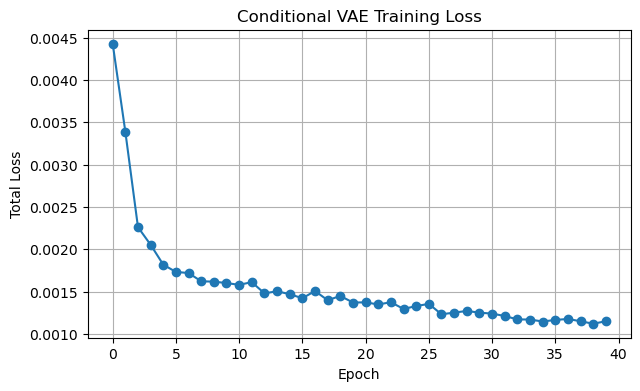

In [38]:
# Task 2B - Step 5: Plot training loss

plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Conditional VAE Training Loss")
plt.grid(True)
plt.show()

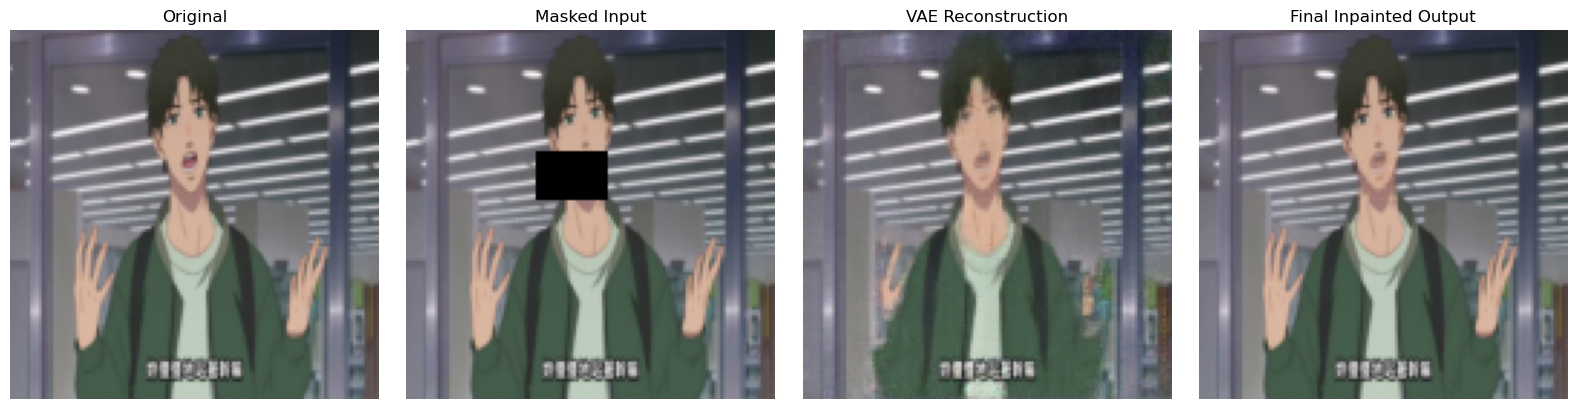

In [ ]:
# Task 2B - Step 6: Apply trained VAE to one example

vae_model.eval()

with torch.no_grad():
    model_input, target, mask = next(iter(vae_loader))

    model_input = model_input.to(device)
    target = target.to(device)
    mask = mask.to(device)

    recon, mu, logvar = vae_model(model_input)

# Take first example from batch
input_img = model_input[0, :3].detach().cpu()
target_img = target[0].detach().cpu()
mask_img = mask[0].detach().cpu()
recon_img = recon[0].detach().cpu()

# Combine known pixels from original with reconstructed pixels inside mask
final_img = target_img * (1 - mask_img) + recon_img * mask_img


def tensor_to_img(t):
    return t.permute(1, 2, 0).numpy().clip(0, 1)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(tensor_to_img(target_img))
axes[0].set_title("Original")

axes[1].imshow(tensor_to_img(input_img))
axes[1].set_title("Masked Input")

axes[2].imshow(tensor_to_img(recon_img))
axes[2].set_title("VAE Reconstruction")

axes[3].imshow(tensor_to_img(final_img))
axes[3].set_title("Final Inpainted Output")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Additional Experiment: Stronger Conditional VAE Baseline

To further test a no-prior baseline, we trained a stronger conditional VAE using frames sampled from all available anime clips. This model is trained from scratch and does not use Stable Diffusion, a text prompt, or any pretrained image prior.

The input is the masked RGB frame concatenated with the binary mask:

$$
[x_t \odot (1 - m_t), m_t]
$$

The VAE reconstructs the image through a latent variable $z$:

$$
z \sim q_{\phi}(z \mid x_t \odot (1 - m_t), m_t)
$$

$$
\hat{x}_t = p_{\theta}(x_t \mid z)
$$

The objective combines masked reconstruction loss and KL divergence:

$$
\mathcal{L}
=
\left\|
m_t \odot (\hat{x}_t - x_t)
\right\|_1
+
\beta D_{KL}
\left(
q_{\phi}(z \mid x_t \odot (1 - m_t), m_t)
\;\|\;
\mathcal{N}(0, I)
\right)
$$

This experiment gives a fairer comparison against the diffusion pipeline by using more local data and a longer training run.

Using device: cpu
Number of clips found: 25


Sampling frames from clips: 100%|██████████| 25/25 [00:12<00:00,  2.08it/s]

Total sampled frames: 1000


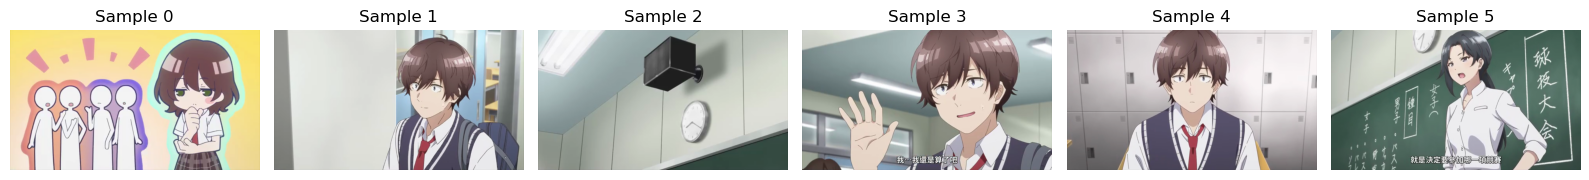

In [40]:
# Strong Conditional VAE - Step 1: Sample training frames from all local clips

import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Use the existing video_paths from the notebook
print("Number of clips found:", len(video_paths))

# You can increase this if you want a longer run
FRAMES_PER_CLIP = 40
MAX_CLIPS = min(25, len(video_paths))

sampled_frames = []

for vp in tqdm(video_paths[:MAX_CLIPS], desc="Sampling frames from clips"):
    cap = cv2.VideoCapture(str(vp))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        continue

    # Avoid extreme beginning/end frames
    start = int(total_frames * 0.1)
    end = int(total_frames * 0.9)

    if end <= start:
        start = 0
        end = total_frames - 1

    frame_ids = np.linspace(start, end, FRAMES_PER_CLIP).astype(int)

    for fid in frame_ids:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
        ret, frame_bgr = cap.read()

        if ret and frame_bgr is not None:
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            sampled_frames.append(frame_rgb)

    cap.release()

print("Total sampled frames:", len(sampled_frames))

# Preview a few sampled frames
preview_count = min(6, len(sampled_frames))
fig, axes = plt.subplots(1, preview_count, figsize=(16, 4))

if preview_count == 1:
    axes = [axes]

for i in range(preview_count):
    axes[i].imshow(sampled_frames[i])
    axes[i].set_title(f"Sample {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Strong Conditional VAE - Step 2: Dataset with varied random masks


class StrongAnimeVAEDataset(Dataset):
    def __init__(self, frames, image_size=128, num_augments_per_frame=5):
        self.frames = frames
        self.image_size = image_size
        self.num_augments_per_frame = num_augments_per_frame

    def __len__(self):
        return len(self.frames) * self.num_augments_per_frame

    def random_mask(self, h, w):
        mask = np.zeros((h, w), dtype=np.float32)

        # Random rectangle mask
        mask_h = random.randint(h // 8, h // 3)
        mask_w = random.randint(w // 8, w // 3)

        y1 = random.randint(0, h - mask_h)
        x1 = random.randint(0, w - mask_w)

        mask[y1 : y1 + mask_h, x1 : x1 + mask_w] = 1.0

        # Occasionally add a second smaller missing region
        if random.random() < 0.35:
            mask_h2 = random.randint(h // 12, h // 5)
            mask_w2 = random.randint(w // 12, w // 5)

            y2 = random.randint(0, h - mask_h2)
            x2 = random.randint(0, w - mask_w2)

            mask[y2 : y2 + mask_h2, x2 : x2 + mask_w2] = 1.0

        return mask

    def __getitem__(self, idx):
        frame_idx = idx % len(self.frames)

        img = Image.fromarray(self.frames[frame_idx].astype(np.uint8)).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.Resampling.BILINEAR)

        img_np = np.array(img).astype(np.float32) / 255.0
        h, w, _ = img_np.shape

        mask_np = self.random_mask(h, w)

        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).float()

        masked_img = img_tensor * (1 - mask_tensor)

        # 4-channel conditional input: masked RGB + mask
        model_input = torch.cat([masked_img, mask_tensor], dim=0)

        return model_input, img_tensor, mask_tensor


strong_vae_dataset = StrongAnimeVAEDataset(
    frames=sampled_frames, image_size=128, num_augments_per_frame=5
)

strong_vae_loader = DataLoader(strong_vae_dataset, batch_size=16, shuffle=True)

print("Total training examples:", len(strong_vae_dataset))

sample_input, sample_target, sample_mask = next(iter(strong_vae_loader))
print("Input shape:", sample_input.shape)
print("Target shape:", sample_target.shape)
print("Mask shape:", sample_mask.shape)

Total training examples: 5000
Input shape: torch.Size([16, 4, 128, 128])
Target shape: torch.Size([16, 3, 128, 128])
Mask shape: torch.Size([16, 1, 128, 128])


In [ ]:
# Strong Conditional VAE - Step 3: Define stronger conditional VAE model


class StrongConditionalVAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder: input has 4 channels = masked RGB + mask
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # 64x64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1),  # 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )

        self.flatten_dim = 512 * 4 * 4

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # 128x128
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 512, 4, 4)

        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)

        return recon, mu, logvar


strong_vae_model = StrongConditionalVAE(latent_dim=256).to(device)

print(strong_vae_model)

StrongConditionalVAE(
  (encoder): Sequential(
    (0): Conv2d(4, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
    (12): Conv2d(512, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, af

In [ ]:
# Strong Conditional VAE - Step 4: Train stronger VAE


def strong_vae_loss_function(recon, target, mask, mu, logvar, beta=0.0005):
    # Reconstruction loss only on masked region
    masked_l1 = torch.mean(torch.abs(mask * (recon - target)))

    # Small full-image loss helps preserve global colors/structure
    full_l1 = 0.1 * torch.mean(torch.abs(recon - target))

    # KL divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = masked_l1 + full_l1 + beta * kl_loss

    return total_loss, masked_l1, full_l1, kl_loss


strong_optimizer = torch.optim.Adam(strong_vae_model.parameters(), lr=5e-4)

num_epochs = 25
beta = 0.0005

strong_train_losses = []

strong_vae_model.train()

for epoch in range(num_epochs):
    epoch_total = 0
    epoch_masked = 0
    epoch_full = 0
    epoch_kl = 0

    for model_input, target, mask in strong_vae_loader:
        model_input = model_input.to(device)
        target = target.to(device)
        mask = mask.to(device)

        recon, mu, logvar = strong_vae_model(model_input)

        loss, masked_l1, full_l1, kl_loss = strong_vae_loss_function(
            recon, target, mask, mu, logvar, beta=beta
        )

        strong_optimizer.zero_grad()
        loss.backward()
        strong_optimizer.step()

        epoch_total += loss.item()
        epoch_masked += masked_l1.item()
        epoch_full += full_l1.item()
        epoch_kl += kl_loss.item()

    avg_total = epoch_total / len(strong_vae_loader)
    avg_masked = epoch_masked / len(strong_vae_loader)
    avg_full = epoch_full / len(strong_vae_loader)
    avg_kl = epoch_kl / len(strong_vae_loader)

    strong_train_losses.append(avg_total)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Total: {avg_total:.4f} | "
        f"Masked L1: {avg_masked:.4f} | "
        f"Full L1: {avg_full:.4f} | "
        f"KL: {avg_kl:.4f}"
    )

KeyboardInterrupt: 

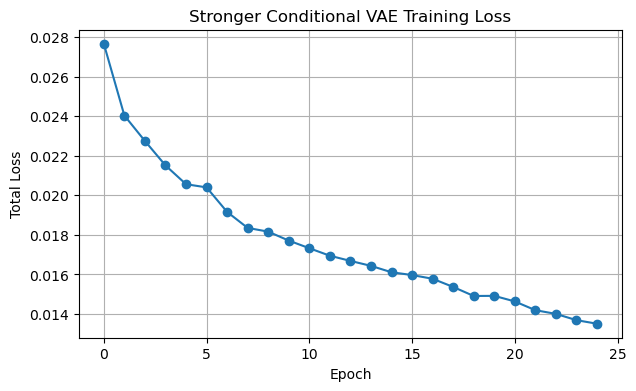

In [44]:
# Plot stronger VAE training loss

plt.figure(figsize=(7, 4))
plt.plot(strong_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Stronger Conditional VAE Training Loss")
plt.grid(True)
plt.show()

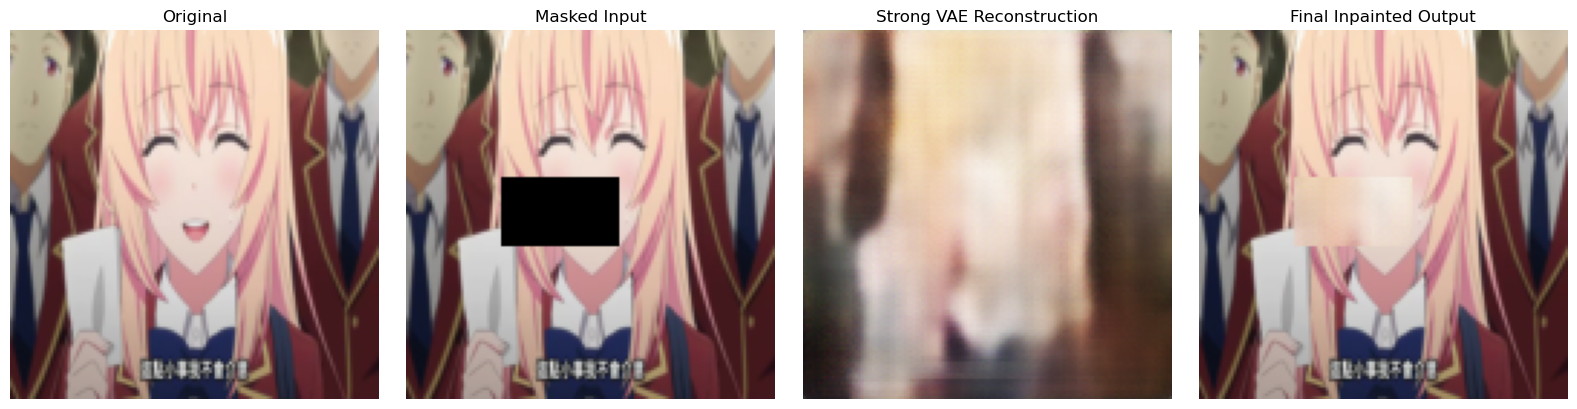

In [ ]:
# Strong Conditional VAE - Step 5: Visualize inpainting output

strong_vae_model.eval()

with torch.no_grad():
    model_input, target, mask = next(iter(strong_vae_loader))

    model_input = model_input.to(device)
    target = target.to(device)
    mask = mask.to(device)

    recon, mu, logvar = strong_vae_model(model_input)

# Take first example
input_img = model_input[0, :3].detach().cpu()
target_img = target[0].detach().cpu()
mask_img = mask[0].detach().cpu()
recon_img = recon[0].detach().cpu()

# Keep original known pixels and use VAE only inside the mask
final_img = target_img * (1 - mask_img) + recon_img * mask_img


def tensor_to_img(t):
    return t.permute(1, 2, 0).numpy().clip(0, 1)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(tensor_to_img(target_img))
axes[0].set_title("Original")

axes[1].imshow(tensor_to_img(input_img))
axes[1].set_title("Masked Input")

axes[2].imshow(tensor_to_img(recon_img))
axes[2].set_title("Strong VAE Reconstruction")

axes[3].imshow(tensor_to_img(final_img))
axes[3].set_title("Final Inpainted Output")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Task 3: Prior-Guided Inpainting with Guidance Strength Analysis

For Task 3, we evaluate how changing the guidance strength affects reconstruction quality. In this notebook, the pretrained Stable Diffusion Inpainting model acts as the generative prior. Instead of training a model from scratch, we use the pretrained diffusion model’s learned image distribution as a prior for plausible anime-style reconstructions.

We vary the guidance strength parameter \(\lambda\), represented in the implementation using different guidance scale values. Higher guidance values force the model to follow the prompt and learned prior more strongly, while lower values allow more flexibility.

We evaluate outputs generated under different guidance strengths:

$$
\hat{x}_{\lambda} = f_{\theta}(x, m, c, \lambda)
$$

where:

- $x$ is the original frame,
- $m$ is the binary mask,
- $c$ is the text prompt,
- $\lambda$ controls the strength of prior guidance,
- $\hat{x}_{\lambda}$ is the reconstructed image.

In [19]:
# Task III setup check: make sure required variables exist

required_vars = [
    "inpaint_pipe",
    "init_image",
    "mask_image",
    "prompt",
    "negative_prompt",
]

for v in required_vars:
    print(v, "exists:", v in globals())

print("init_image size:", init_image.size)
print("mask_image size:", mask_image.size)

inpaint_pipe exists: True
init_image exists: True
mask_image exists: True
prompt exists: True
negative_prompt exists: True
init_image size: (640, 360)
mask_image size: (640, 360)


In [20]:
# Run multiple guidance scales for comparison

import matplotlib.pyplot as plt

guidance_scales = [3, 5, 6, 7, 10]

results = []

W, H = init_image.size

for gs in guidance_scales:
    print(f"Running guidance_scale = {gs}")

    out = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=init_image,
        mask_image=mask_image,
        height=H,
        width=W,
        num_inference_steps=25,
        guidance_scale=gs,
        strength=0.7,
    ).images[0]

    results.append(out)

print("Finished all guidance runs")

Running guidance_scale = 3


  0%|          | 0/17 [00:00<?, ?it/s]

Running guidance_scale = 5


  0%|          | 0/17 [00:00<?, ?it/s]

Running guidance_scale = 6


...

Running guidance_scale = 7


  0%|          | 0/17 [00:00<?, ?it/s]

Running guidance_scale = 10


  0%|          | 0/17 [00:00<?, ?it/s]

Finished all guidance runs


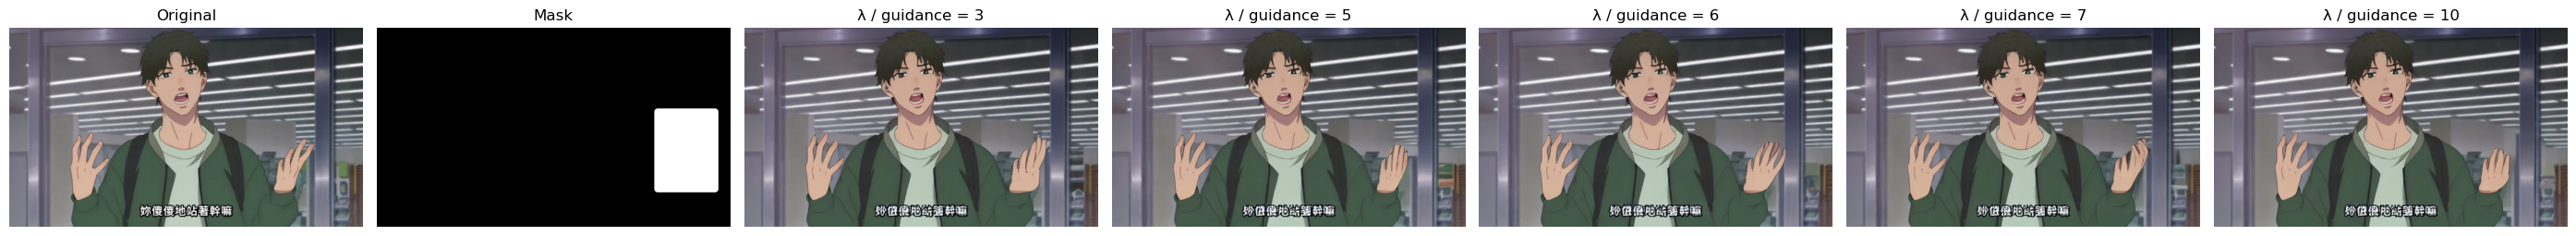

In [21]:
# Compare results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(results) + 2, figsize=(4 * (len(results) + 2), 4))

axes[0].imshow(init_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask_image, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

for i, (gs, img) in enumerate(zip(guidance_scales, results), start=2):
    axes[i].imshow(img)
    axes[i].set_title(f"λ / guidance = {gs}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [22]:
# Step 1: Imports + metric setup

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image

# Image quality metrics
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# LPIPS for perceptual realism
# If this import fails, run: !pip install lpips
import lpips

device = "cuda" if torch.cuda.is_available() else "cpu"

lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()

print("Using device:", device)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/arushisingh/miniconda3/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Using device: cpu


/Users/arushisingh/miniconda3/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/arushisingh/miniconda3/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [23]:
# Step 2: Convert images to clean RGB numpy arrays


def to_rgb_numpy(img):
    """
    Converts PIL image or numpy array to RGB numpy array in [0, 255].
    """
    if isinstance(img, Image.Image):
        img = img.convert("RGB")
        arr = np.array(img)
    else:
        arr = np.array(img)

        # If normalized float image, convert to 0-255
        if arr.max() <= 1.0:
            arr = (arr * 255).astype(np.uint8)

        # If grayscale, convert to RGB
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)

        # If RGBA, remove alpha
        if arr.shape[-1] == 4:
            arr = arr[..., :3]

    return arr.astype(np.uint8)


original_np = to_rgb_numpy(init_image)

result_arrays = []
for img in results:
    result_arrays.append(to_rgb_numpy(img))

print("Original shape:", original_np.shape)
print("Number of generated results:", len(result_arrays))

for gs, arr in zip(guidance_scales, result_arrays):
    print(
        f"alpha / guidance = {gs}: shape = {arr.shape}, min = {arr.min()}, max = {arr.max()}"
    )

Original shape: (360, 640, 3)
Number of generated results: 5
alpha / guidance = 3: shape = (360, 640, 3), min = 0, max = 255
alpha / guidance = 5: shape = (360, 640, 3), min = 0, max = 255
alpha / guidance = 6: shape = (360, 640, 3), min = 0, max = 255
alpha / guidance = 7: shape = (360, 640, 3), min = 0, max = 255
alpha / guidance = 10: shape = (360, 640, 3), min = 0, max = 255


## Task 4: Quantitative Evaluation

We evaluate each guidance setting using:

- **PSNR**: pixel-level reconstruction accuracy, higher is better.
- **SSIM**: structural similarity, higher is better.
- **LPIPS**: perceptual realism, lower is better.
- **Frame-difference consistency**: simple temporal/consistency-style metric, lower is better.

In [24]:
# Step 3: Compute PSNR, SSIM, and LPIPS for each alpha / guidance value


def image_to_lpips_tensor(arr):
    """
    Converts RGB image array in [0, 255] to LPIPS tensor in [-1, 1].
    Shape: (1, 3, H, W)
    """
    tensor = torch.from_numpy(arr).float() / 255.0
    tensor = tensor.permute(2, 0, 1).unsqueeze(0)
    tensor = tensor * 2 - 1
    return tensor.to(device)


original_tensor = image_to_lpips_tensor(original_np)

metric_rows = []

for gs, gen_np in zip(guidance_scales, result_arrays):
    # PSNR: higher is better
    psnr_value = psnr(original_np, gen_np, data_range=255)

    # SSIM: higher is better
    ssim_value = ssim(original_np, gen_np, channel_axis=2, data_range=255)

    # LPIPS: lower is better
    gen_tensor = image_to_lpips_tensor(gen_np)

    with torch.no_grad():
        lpips_value = lpips_model(original_tensor, gen_tensor).item()

    metric_rows.append(
        {
            "alpha_guidance": gs,
            "PSNR_higher_better": psnr_value,
            "SSIM_higher_better": ssim_value,
            "LPIPS_lower_better": lpips_value,
        }
    )

metrics_df = pd.DataFrame(metric_rows)
metrics_df

,alpha_guidance,PSNR_higher_better,SSIM_higher_better,LPIPS_lower_better
0,3,24.964680,0.929613,0.049565
1,5,25.407981,0.927140,0.046712
2,6,25.064439,0.926779,0.051647
3,7,25.130019,0.928643,0.048317
4,10,25.343514,0.929819,0.049919


In [25]:
# Step 4: Temporal / consistency-style metric across guidance outputs
# This measures how much each generated output changes compared to the previous alpha.
# Lower values mean outputs are more stable/consistent across nearby guidance strengths.


def mean_frame_difference(img_a, img_b):
    """
    Computes average pixel difference between two RGB images.
    Lower = more consistent.
    """
    img_a = img_a.astype(np.float32) / 255.0
    img_b = img_b.astype(np.float32) / 255.0
    return np.mean(np.abs(img_a - img_b))


temporal_rows = []

for i in range(1, len(result_arrays)):
    prev_alpha = guidance_scales[i - 1]
    curr_alpha = guidance_scales[i]

    diff_value = mean_frame_difference(result_arrays[i - 1], result_arrays[i])

    temporal_rows.append(
        {
            "alpha_transition": f"{prev_alpha} → {curr_alpha}",
            "previous_alpha": prev_alpha,
            "current_alpha": curr_alpha,
            "frame_difference_lower_better": diff_value,
        }
    )

temporal_df = pd.DataFrame(temporal_rows)
temporal_df

,alpha_transition,previous_alpha,current_alpha,frame_difference_lower_better
0,3 → 5,3,5,0.011273
1,5 → 6,5,6,0.011505
2,6 → 7,6,7,0.013514
3,7 → 10,7,10,0.010695
